In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
crop_ndvi_df = pd.read_csv(
    "../outputs/makueni_monthly_ndvi_cropland_2023_2024.csv"
)

rain_df = pd.read_csv(
    "../outputs/makueni_monthly_rainfall_2023_2024.csv"
)

In [3]:
crop_ndvi_df["month"] = pd.to_datetime(crop_ndvi_df["month"])
rain_df["month"] = pd.to_datetime(rain_df["month"])

In [4]:
main_df = crop_ndvi_df.merge(
    rain_df,
    on="month"
)

main_df.head()

,month,mean_ndvi_cropland,rainfall_mm
0,2023-01-01,0.436175,14.535096
1,2023-02-01,0.260122,3.766772
2,2023-03-01,0.219531,61.026191
3,2023-04-01,0.322423,165.047111
4,2023-05-01,0.294409,33.181699


In [5]:
main_df["rainfall_lag1"] = main_df["rainfall_mm"].shift(1)
main_df["rainfall_lag2"] = main_df["rainfall_mm"].shift(2)

In [6]:
main_df[
    [
        "mean_ndvi_cropland",
        "rainfall_mm",
        "rainfall_lag1",
        "rainfall_lag2"
    ]
].corr()

,mean_ndvi_cropland,rainfall_mm,rainfall_lag1,rainfall_lag2
mean_ndvi_cropland,1.000000,0.239038,0.694773,0.652294
rainfall_mm,0.239038,1.000000,0.155689,-0.198703
rainfall_lag1,0.694773,0.155689,1.000000,0.144214
rainfall_lag2,0.652294,-0.198703,0.144214,1.000000


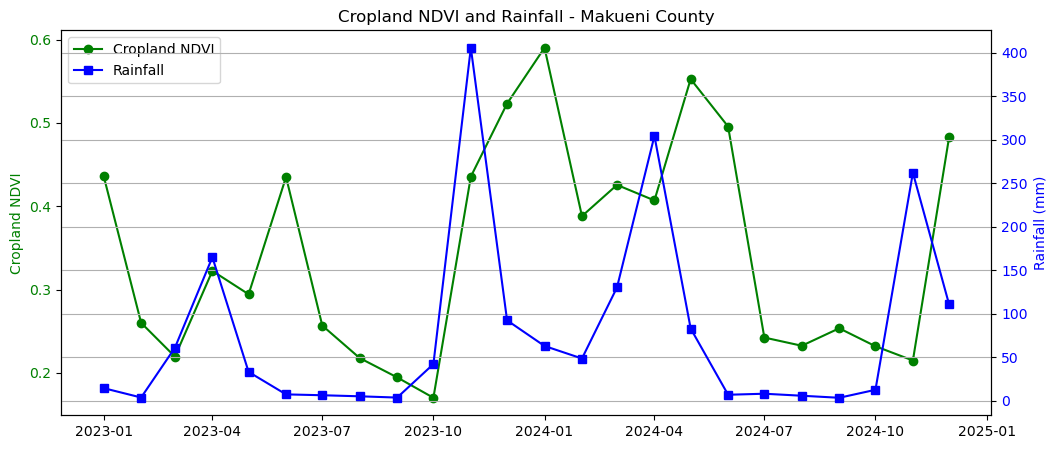

In [7]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    main_df["month"],
    main_df["mean_ndvi_cropland"],
    marker="o",
    color="green",
    label="Cropland NDVI"
)

ax1.set_ylabel("Cropland NDVI", color="green")
ax1.tick_params(axis="y", labelcolor="green")

ax2 = ax1.twinx()

ax2.plot(
    main_df["month"],
    main_df["rainfall_mm"],
    marker="s",
    color="blue",
    label="Rainfall"
)

ax2.set_ylabel("Rainfall (mm)", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Cropland NDVI and Rainfall - Makueni County")
plt.grid(True)

fig.savefig(
    "../docs/images/makueni_cropland_ndvi_rainfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

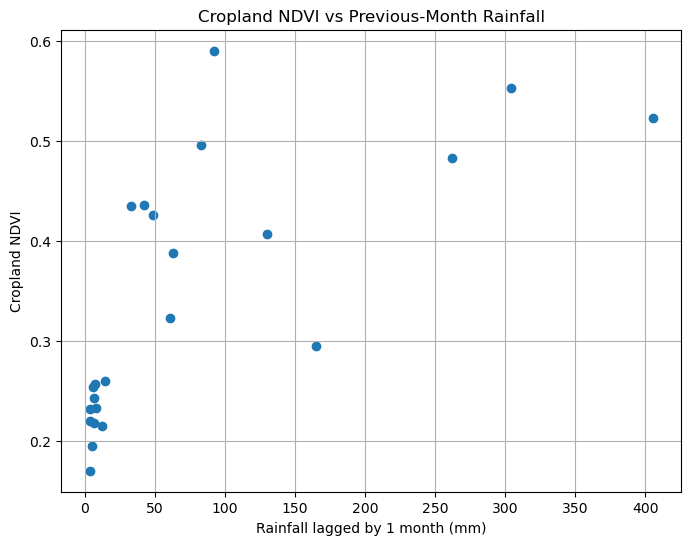

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    main_df["rainfall_lag1"],
    main_df["mean_ndvi_cropland"]
)

plt.xlabel("Rainfall lagged by 1 month (mm)")
plt.ylabel("Cropland NDVI")
plt.title("Cropland NDVI vs Previous-Month Rainfall")
plt.grid(True)

plt.show()